In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("CyberSentinel AI - Data Science Environment Ready!")

CyberSentinel AI - Data Science Environment Ready!


# 🛡️ CyberSentinel AI

## Network Threat Detection & Anomaly Analysis

This notebook contains the initial exploration and analysis of cybersecurity network traffic data.

### Objectives

- Understand the cybersecurity dataset
- Identify normal and malicious traffic
- Explore network traffic features
- Analyze class imbalance
- Prepare data for machine learning

In [3]:
from pathlib import Path
import pandas as pd

# Dataset location
DATA_DIR = Path("../data/raw/CIC-IDS2017")

# Find all CSV files
csv_files = sorted(DATA_DIR.glob("*.csv"))

print(f"CSV files found: {len(csv_files)}")

for file in csv_files:
    print("•", file.name)

CSV files found: 8
• Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
• Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
• Friday-WorkingHours-Morning.pcap_ISCX.csv
• Monday-WorkingHours.pcap_ISCX.csv
• Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
• Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
• Tuesday-WorkingHours.pcap_ISCX.csv
• Wednesday-workingHours.pcap_ISCX.csv


In [4]:
# Select the first CSV file
sample_file = csv_files[0]

# Read only 5 rows
sample_df = pd.read_csv(sample_file, nrows=5)

print("File:", sample_file.name)
print("Sample shape:", sample_df.shape)

File: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Sample shape: (5, 85)


In [5]:
sample_df.head()

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.10.5-104.16.207.165-54865-443-6,104.16.207.165,443,192.168.10.5,54865,6,7/7/2017 3:30,3,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,192.168.10.5-104.16.28.216-55054-80-6,104.16.28.216,80,192.168.10.5,55054,6,7/7/2017 3:30,109,1,1,...,20,0,0,0,0,0,0,0,0,BENIGN
2,192.168.10.5-104.16.28.216-55055-80-6,104.16.28.216,80,192.168.10.5,55055,6,7/7/2017 3:30,52,1,1,...,20,0,0,0,0,0,0,0,0,BENIGN
3,192.168.10.16-104.17.241.25-46236-443-6,104.17.241.25,443,192.168.10.16,46236,6,7/7/2017 3:30,34,1,1,...,20,0,0,0,0,0,0,0,0,BENIGN
4,192.168.10.5-104.19.196.102-54863-443-6,104.19.196.102,443,192.168.10.5,54863,6,7/7/2017 3:30,3,2,0,...,20,0,0,0,0,0,0,0,0,BENIGN


In [6]:
print("Number of columns:", len(sample_df.columns))
print("\nColumn names:")
print(sample_df.columns.tolist())

Number of columns: 85

Column names:
['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet

In [7]:
# Remove leading and trailing spaces from column names
sample_df.columns = sample_df.columns.str.strip()

print("Number of columns:", len(sample_df.columns))
print("\nCleaned column names:")
print(sample_df.columns.tolist())

Number of columns: 85

Cleaned column names:
['Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Coun

In [8]:
print("Target column:", sample_df.columns[-1])
print("\nLabels in sample:")
print(sample_df["Label"].value_counts())

Target column: Label

Labels in sample:
Label
BENIGN    5
Name: count, dtype: int64


In [9]:
# Load the first dataset completely
df = pd.read_csv(csv_files[0])

# Clean column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (225745, 85)


In [10]:
print("Number of unique labels:", df["Label"].nunique())

print("\nTraffic labels:")
print(df["Label"].value_counts())

Number of unique labels: 2

Traffic labels:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


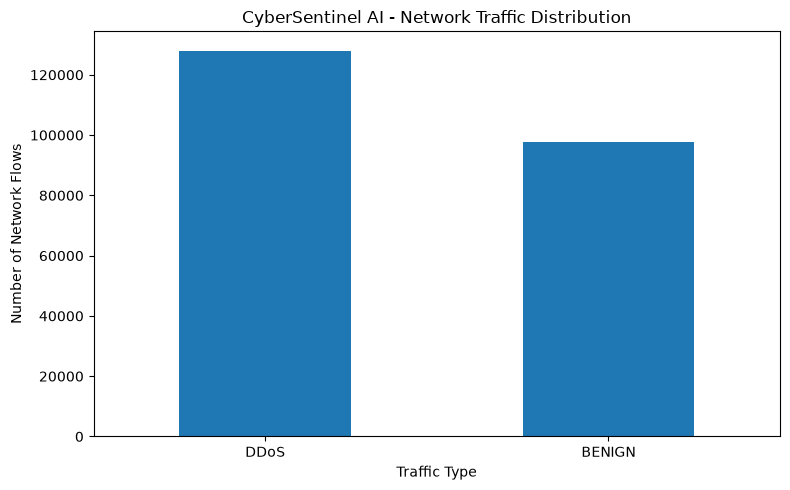

In [11]:
# Count each traffic type
label_counts = df["Label"].value_counts()

# Create a bar chart
plt.figure(figsize=(8, 5))

label_counts.plot(kind="bar")

plt.title("CyberSentinel AI - Network Traffic Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Network Flows")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
# Calculate percentage distribution
label_percentage = df["Label"].value_counts(normalize=True) * 100

print("Traffic Distribution (%)")
print(label_percentage.round(2))

Traffic Distribution (%)
Label
DDoS      56.71
BENIGN    43.29
Name: proportion, dtype: float64


In [13]:
# Check for missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

Total missing values: 4

Columns containing missing values:
Flow Bytes/s    4
dtype: int64


In [14]:
import numpy as np

# Check for infinite values
numeric_df = df.select_dtypes(include=np.number)

infinite_values = np.isinf(numeric_df).sum()

print("Total infinite values:", infinite_values.sum())

print("\nColumns containing infinite values:")
print(infinite_values[infinite_values > 0])

Total infinite values: 64

Columns containing infinite values:
Flow Bytes/s      30
Flow Packets/s    34
dtype: int64


In [15]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Infinite values remaining:", np.isinf(
    df.select_dtypes(include=np.number)
).sum().sum())

Infinite values remaining: 0


In [16]:
# Check missing values after converting infinity to NaN
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

print("\nColumns containing missing values:")
print(missing_values[missing_values > 0])

Total missing values: 68

Columns containing missing values:
Flow Bytes/s      34
Flow Packets/s    34
dtype: int64


In [17]:
# Remove rows containing missing values
before = len(df)

df.dropna(inplace=True)

after = len(df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)

Rows before cleaning: 225745
Rows after cleaning: 225711
Rows removed: 34


In [18]:
# Separate features and target

X = df.drop(columns=["Label"])
y = df["Label"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (225711, 84)
Target (y): (225711,)


In [19]:
print("Target classes:")
print(y.value_counts())

Target classes:
Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64


In [20]:
# Check data types of all features

print("Numeric features:", X.select_dtypes(include=np.number).shape[1])
print("Non-numeric features:", X.select_dtypes(exclude=np.number).shape[1])

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=np.number).columns.tolist())

Numeric features: 80
Non-numeric features: 4

Non-numeric columns:
['Flow ID', 'Source IP', 'Destination IP', 'Timestamp']


In [21]:
# Keep only numeric features for the ML model
X_numeric = X.select_dtypes(include=np.number).copy()

print("Original features:", X.shape[1])
print("ML features:", X_numeric.shape[1])
print("Target values:", y.shape[0])

Original features: 84
ML features: 80
Target values: 225711


In [22]:
print("Missing values in X:", X_numeric.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [23]:
# Convert traffic labels into binary values
y_binary = y.map({
    "BENIGN": 0,
    "DDoS": 1
})

print("Encoded target values:")
print(y_binary.value_counts())

Encoded target values:
Label
1    128025
0     97686
Name: count, dtype: int64


In [24]:
print("Original labels:", y.unique())
print("Encoded labels:", y_binary.unique())
print("Missing encoded labels:", y_binary.isnull().sum())

Original labels: <StringArray>
['BENIGN', 'DDoS']
Length: 2, dtype: str
Encoded labels: [0 1]
Missing encoded labels: 0


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_numeric,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training data: (180568, 80)
Testing data: (45143, 80)
Training labels: (180568,)
Testing labels: (45143,)


In [26]:
# Check feature statistics
feature_stats = X_train.describe().T

feature_stats[["min", "max", "mean", "std"]].head(20)

,min,max,mean,std
Source Port,0.0,6.553400e+04,3.826837e+04,2.305462e+04
Destination Port,0.0,6.553200e+04,8.867753e+03,1.974291e+04
Protocol,0.0,1.700000e+01,7.600926e+00,3.882070e+00
Flow Duration,-1.0,1.199999e+08,1.626439e+07,3.153758e+07
Total Fwd Packets,1.0,1.932000e+03,4.876927e+00,1.556737e+01
Total Backward Packets,0.0,2.942000e+03,4.580518e+00,2.205974e+01
Total Length of Fwd Packets,0.0,1.830120e+05,9.417024e+02,3.242222e+03
Total Length of Bwd Packets,0.0,4.991419e+06,5.971295e+03,3.947103e+04
Fwd Packet Length Max,0.0,1.168000e+04,5.384710e+02,1.863319e+03
Fwd Packet Length Min,0.0,1.472000e+03,2.775985e+01,1.628216e+02


In [27]:
# Find features with the largest maximum values

largest_features = (
    X_train.max()
    .sort_values(ascending=False)
    .head(15)
)

print(largest_features)

Flow Bytes/s     2.070000e+09
Fwd IAT Max      1.200000e+08
Bwd IAT Total    1.200000e+08
Fwd IAT Min      1.200000e+08
Idle Mean        1.200000e+08
Idle Max         1.200000e+08
Bwd IAT Max      1.200000e+08
Idle Min         1.200000e+08
Flow IAT Max     1.200000e+08
Fwd IAT Total    1.200000e+08
Fwd IAT Mean     1.200000e+08
Bwd IAT Mean     1.200000e+08
Bwd IAT Min      1.200000e+08
Flow Duration    1.199999e+08
Active Mean      1.000000e+08
dtype: float64


In [28]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler on test data
X_test_scaled = scaler.transform(X_test)

print("Original training shape:", X_train.shape)
print("Scaled training shape:", X_train_scaled.shape)

print("Original testing shape:", X_test.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Original training shape: (180568, 80)
Scaled training shape: (180568, 80)
Original testing shape: (45143, 80)
Scaled testing shape: (45143, 80)


In [29]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

print("✅ Random Forest training complete!")

Training Random Forest...
✅ Random Forest training complete!


In [30]:
# Make predictions on the unseen test data
y_pred = rf_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 45143


In [31]:
print("First 20 predictions:")
print(y_pred[:20])

print("\nFirst 20 actual values:")
print(y_test.to_numpy()[:20])

First 20 predictions:
[1 1 0 0 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 0]

First 20 actual values:
[1 1 0 0 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 0]


In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9999
Precision: 0.9999
Recall   : 0.9999
F1-Score : 0.9999


In [33]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["BENIGN", "DDoS"]
))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



Confusion Matrix:
[[19536     2]
 [    3 25602]]


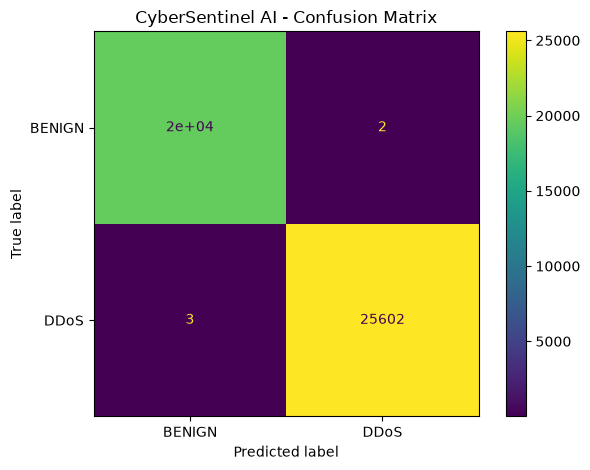

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Visualize
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "DDoS"]
)

disp.plot()
plt.title("CyberSentinel AI - Confusion Matrix")
plt.tight_layout()
plt.show()

In [35]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_numeric.columns,
    "Importance": rf_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 most important features:")
print(feature_importance.head(15))

Top 15 most important features:
                        Feature  Importance
10       Fwd Packet Length Mean    0.102662
55         Avg Fwd Segment Size    0.070755
8         Fwd Packet Length Max    0.067229
70             act_data_pkt_fwd    0.062322
24                  Fwd IAT Std    0.057267
4             Total Fwd Packets    0.047730
65            Subflow Fwd Bytes    0.044371
68       Init_Win_bytes_forward    0.043637
57          Fwd Header Length.1    0.042334
6   Total Length of Fwd Packets    0.041831
25                  Fwd IAT Max    0.039881
1              Destination Port    0.037213
13        Bwd Packet Length Min    0.025654
23                 Fwd IAT Mean    0.025412
37            Bwd Header Length    0.021865


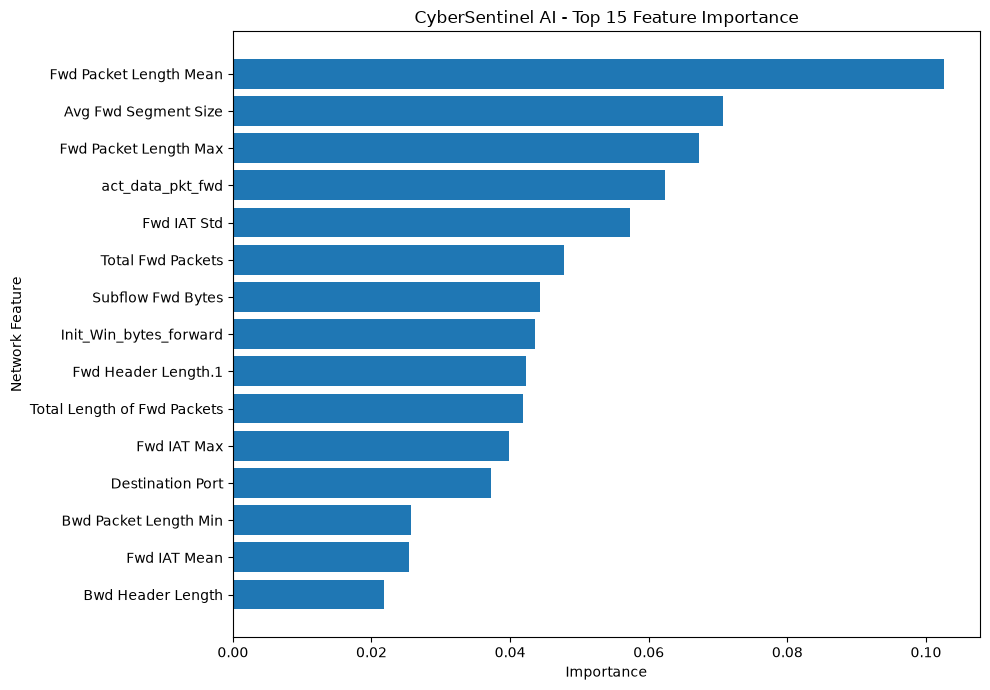

In [36]:
# Visualize top 15 features

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("CyberSentinel AI - Top 15 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Network Feature")

plt.tight_layout()
plt.show()

In [37]:
import joblib
from pathlib import Path

# Make sure the models directory exists
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save the trained model
joblib.dump(rf_model, MODEL_DIR / "random_forest_ddos.joblib")

# Save the scaler
joblib.dump(scaler, MODEL_DIR / "feature_scaler.joblib")

print("✅ Model saved successfully!")
print("✅ Scaler saved successfully!")

✅ Model saved successfully!
✅ Scaler saved successfully!


In [38]:
print("Saved model files:")

for file in MODEL_DIR.iterdir():
    print("•", file.name)

Saved model files:
• feature_scaler.joblib
• random_forest_ddos.joblib


In [39]:
import json

feature_columns = X_numeric.columns.tolist()

with open(MODEL_DIR / "feature_columns.json", "w") as f:
    json.dump(feature_columns, f, indent=2)

print("✅ Feature schema saved!")
print("Number of features:", len(feature_columns))
print("Saved as:", MODEL_DIR / "feature_columns.json")

✅ Feature schema saved!
Number of features: 80
Saved as: ..\models\feature_columns.json


In [40]:
print("Model files:")

for file in MODEL_DIR.iterdir():
    print("•", file.name)

Model files:
• feature_columns.json
• feature_scaler.joblib
• random_forest_ddos.joblib


In [41]:
def predict_threat(input_df):
    # Keep features in the exact order used during training
    input_features = input_df[feature_columns]

    # Apply the saved scaler
    input_scaled = scaler.transform(input_features)

    # Make prediction
    prediction = rf_model.predict(input_scaled)[0]

    # Get probability
    probabilities = rf_model.predict_proba(input_scaled)[0]

    # Calculate risk score
    risk_score = probabilities[1] * 100

    # Convert prediction to readable label
    label = "DDoS" if prediction == 1 else "BENIGN"

    return {
        "prediction": label,
        "risk_score": round(risk_score, 2),
        "benign_probability": round(probabilities[0] * 100, 2),
        "ddos_probability": round(probabilities[1] * 100, 2)
    }

print("✅ Threat prediction function created!")

✅ Threat prediction function created!


In [42]:
sample_input = X_test.iloc[[0]]

result = predict_threat(sample_input)

print("Prediction Result:")
print(result)

Prediction Result:
{'prediction': 'DDoS', 'risk_score': np.float64(100.0), 'benign_probability': np.float64(0.0), 'ddos_probability': np.float64(100.0)}


In [43]:
import shap

print("Creating SHAP explainer...")

explainer = shap.TreeExplainer(rf_model)

print("✅ SHAP explainer created successfully!")

Creating SHAP explainer...
✅ SHAP explainer created successfully!


In [44]:
# Select one test network flow
sample = X_test.iloc[[0]]

# Calculate SHAP values
shap_values = explainer.shap_values(sample)

print("✅ SHAP values calculated!")
print("Sample shape:", sample.shape)

✅ SHAP values calculated!
Sample shape: (1, 80)


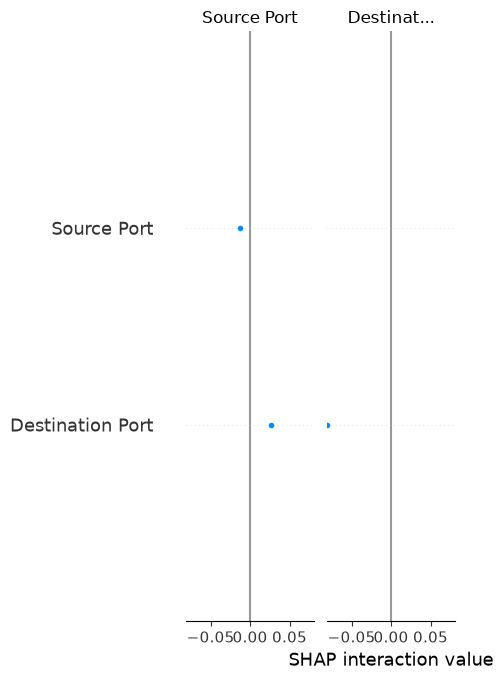

In [45]:
# Create SHAP explanation plot
shap.summary_plot(
    shap_values,
    sample,
    feature_names=feature_columns
)